# Kaggle Semantic Hashing (SimHash + kNN)

This notebook implements a Semantic Hashing baseline using SimHash fingerprints derived from TF-IDF vectors, evaluated on the Kaggle AI-generated vs. human-written phishing email dataset. The pipeline runs in three stages: TF-IDF vectorisation of preprocessed email text, SimHash fingerprint generation from TF-IDF weights, and k-Nearest Neighbour (kNN) classification using Hamming distance between fingerprints. All results use the same metrics schema as every other model in this project (accuracy, F1, FPR, inference time) for direct cross-model comparison.

> **Why SimHash?** SimHash is a locality-sensitive hashing (LSH) technique originally developed for near-duplicate web page detection. Applied to email text, it compresses a sparse TF-IDF vector into a compact binary fingerprint while preserving semantic similarity; documents with similar content produce fingerprints with low Hamming distance. This makes it a computationally lightweight alternative to dense embeddings or neural classifiers.

## 1. Import Libraries

This section imports all libraries needed for data loading, text preprocessing, TF-IDF vectorisation, SimHash fingerprint generation, kNN classification, and evaluation.

In [1]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## 2. Reproducibility and Configuration

A fixed random seed ensures reproducibility. All key hyperparameters and file paths are defined here in one place.

TF-IDF uses `max_features=10000` to cap the vocabulary at the 10,000 most frequent terms, balancing representational richness with computational efficiency; higher values were tested but yielded diminishing returns on validation performance. The `ngram_range=(1, 2)` setting includes unigrams and bigrams to capture short phishing-indicative phrases such as "verify account" and "click here" that single tokens miss. Log-normalisation is applied via `sublinear_tf=True` to reduce the dominance of very common terms.

Hash bit lengths of 64 and 128 are both tested; 128-bit provides finer-grained discrimination between similar documents, while 64-bit is faster. Results for both are reported. For kNN, k values of 1, 3, 5, 7, and 9 are tested, and the best-performing k is used for final evaluation.

In [ ]:
SEED = 42

data_dir    = Path("../data/processed/kaggle/")
results_dir = Path("../results/")
results_dir.mkdir(parents=True, exist_ok=True)

# TF-IDF hyperparameters
TFIDF_MAX_FEATURES = 10000
TFIDF_NGRAM_RANGE  = (1, 2)
TFIDF_SUBLINEAR_TF = True

# SimHash hyperparameters
HASH_BITS_OPTIONS = [64, 128]   # Both are evaluated; best is used for final metrics

# kNN hyperparameters
KNN_K_OPTIONS = [1, 3, 5, 7, 9]  # All tested; best k reported

print("Configuration loaded.")
print(f"  TF-IDF max features : {TFIDF_MAX_FEATURES}")
print(f"  TF-IDF n-gram range : {TFIDF_NGRAM_RANGE}")
print(f"  SimHash bit lengths : {HASH_BITS_OPTIONS}")
print(f"  kNN k values        : {KNN_K_OPTIONS}")

Configuration loaded.
  TF-IDF max features : 10000
  TF-IDF n-gram range : (1, 2)
  SimHash bit lengths : [64, 128]
  kNN k values        : [1, 3, 5, 7, 9]


## 3. Load Processed Data

This section loads the train and test Parquet files produced by `kaggle_preparation.ipynb`. These contain the cleaned `text` and `label` columns.

In [3]:
train_df = pd.read_parquet(data_dir / "kaggle_train_60.parquet")
test_df  = pd.read_parquet(data_dir / "kaggle_test_40.parquet")

print(f"Train size : {len(train_df)} rows")
print(f"Test size  : {len(test_df)} rows")
print(f"Columns    : {train_df.columns.tolist()}")

Train size : 1435 rows
Test size  : 957 rows
Columns    : ['text', 'label', 'source']


## 4. Verify Loaded Data

This section checks label distributions and samples the text field to confirm the data loaded correctly before applying TF-IDF.

In [4]:
print("Train label distribution:")
print(train_df["label"].value_counts())

print("\nTest label distribution:")
print(test_df["label"].value_counts())

train_df[["text", "label"]].head(3)

Train label distribution:
label
0    1034
1     401
Name: count, dtype: int64

Test label distribution:
label
0    690
1    267
Name: count, dtype: int64


,text,label
0,Rachel Thompson COVID-19 Vaccination Team,1
1,Notification: jose@monkey.org Dear jose To c...,1
2,ActiveState evaluation license for Komodo IDE ...,0


## 5. Text Preprocessing

Although the preparation notebook already lowercases and strips punctuation, an additional cleaning step is applied here to remove any residual HTML tags, which phishing emails frequently contain, and to strip stopwords to reduce noise in TF-IDF weights.

Stopword removal is applied at this stage rather than in the preparation notebook because it is specific to the TF-IDF+SimHash pipeline; other models such as BiLSTM benefit from retaining stopwords for sequential context.

In [ ]:
# Minimal stopword list – covers the most frequent English function words
# A full NLTK stopwords list can be substituted if available
STOPWORDS = {
    "a", "an", "the", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "by", "from", "is", "was", "are", "were", "be", "been",
    "being", "have", "has", "had", "do", "does", "did", "will", "would",
    "could", "should", "may", "might", "shall", "can", "need", "that",
    "this", "these", "those", "it", "its", "i", "you", "he", "she", "we",
    "they", "my", "your", "his", "her", "our", "their", "me", "him", "us",
    "them", "not", "no", "so", "if", "as", "up", "out", "about", "into",
    "than", "then", "just", "also", "more", "all", "any", "both", "each",
    "few", "here", "there", "when", "where", "who", "which", "what", "how"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text) # strip HTML tags
    text = re.sub(r"[^a-z\s]", " ", text) # remove non-alpha chars
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return " ".join(tokens)

train_texts  = train_df["text"].apply(clean_text).tolist()
test_texts   = test_df["text"].apply(clean_text).tolist()
train_labels = train_df["label"].values
test_labels  = test_df["label"].values

print(f"Sample cleaned text:\n  {train_texts[0][:200]}")

Sample cleaned text:
  rachel thompson covid vaccination team


## 6. TF-IDF Vectorisation

TF-IDF (Term Frequency–Inverse Document Frequency) converts each email into a sparse vector of weighted term importance scores. The vectorizer fits vocabulary and IDF weights on the training set only to prevent data leakage; the test set is then transformed using that same vocabulary. The resulting sparse matrix is the input to the SimHash stage.

In [6]:
vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    sublinear_tf=TFIDF_SUBLINEAR_TF
)

# Fit on training data only – no test leakage
train_tfidf = vectorizer.fit_transform(train_texts)
test_tfidf  = vectorizer.transform(test_texts)

print(f"TF-IDF train matrix shape : {train_tfidf.shape}")
print(f"TF-IDF test matrix shape  : {test_tfidf.shape}")
print(f"Vocabulary size           : {len(vectorizer.vocabulary_)}")

TF-IDF train matrix shape : (1435, 10000)
TF-IDF test matrix shape  : (957, 10000)
Vocabulary size           : 10000


## 7. SimHash Implementation

SimHash converts a sparse TF-IDF vector into a fixed-length binary fingerprint. For each term in the document, its TF-IDF weight serves as a real-valued vote. Each term maps to a random projection vector drawn from a standard normal distribution, and the weighted sum of projection vectors is computed. Taking the sign of each component produces the binary fingerprint: positive components become 1 and negative components become 0, yielding a fingerprint of length `n_bits`.

Documents with similar TF-IDF content produce fingerprints with low Hamming distance. The random projection matrix is seeded for reproducibility and fitted once on the vocabulary dimension of the training TF-IDF matrix.

In [ ]:
def build_simhash_matrix(tfidf_matrix, n_bits, seed=42):
    """
    Generate SimHash binary fingerprints for a TF-IDF sparse matrix.

    Parameters
    ----------
    tfidf_matrix : sparse matrix, shape (n_docs, vocab_size)
    n_bits       : int, number of bits in the output fingerprint
    seed         : int, random seed for reproducibility

    Returns
    -------
    fingerprints : np.ndarray, shape (n_docs, n_bits), dtype uint8
    """
    rng = np.random.RandomState(seed)
    vocab_size = tfidf_matrix.shape[1]

    # Random projection matrix for SimHash
    # Each bit is defined by a random hyperplane
    projections = rng.randn(vocab_size, n_bits).astype(np.float32)

    # Weighted projection: (n_docs, vocab_size) × (vocab_size, n_bits) → (n_docs, n_bits)
    # Convert to dense before the matrix multiply; this is acceptable at this dataset size
    dense = tfidf_matrix.toarray().astype(np.float32)
    scores = dense @ projections   # shape: (n_docs, n_bits)

    # Binarise: 1 where score > 0, else 0
    fingerprints = (scores > 0).astype(np.uint8)
    return fingerprints


# Generate fingerprints for all bit-length options
train_hashes = {}
test_hashes  = {}

for n_bits in HASH_BITS_OPTIONS:
    print(f"Generating {n_bits}-bit SimHash fingerprints...")
    train_hashes[n_bits] = build_simhash_matrix(train_tfidf, n_bits)
    test_hashes[n_bits]  = build_simhash_matrix(test_tfidf,  n_bits)
    print(f"  Train fingerprint shape : {train_hashes[n_bits].shape}")
    print(f"  Test fingerprint shape  : {test_hashes[n_bits].shape}")

Generating 64-bit SimHash fingerprints...
  Train fingerprint shape : (1435, 64)
  Test fingerprint shape  : (957, 64)
Generating 128-bit SimHash fingerprints...
  Train fingerprint shape : (1435, 128)
  Test fingerprint shape  : (957, 128)


## 8. Hamming Distance and kNN Classification

Hamming distance counts the number of bit positions where two fingerprints differ, and serves as the similarity metric for kNN classification on top of SimHash fingerprints.

`KNeighborsClassifier` with `metric='hamming'` runs directly on the binary fingerprint arrays. Multiple values of k are tested for each hash bit length, and the `n_bits`/`k` combination that achieves the best validation F1 advances to final test evaluation. The section holds out a 10% stratified validation split from the training set for k-selection.

In [ ]:
from sklearn.model_selection import train_test_split

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels)),
    test_size=0.10,
    random_state=SEED,
    stratify=train_labels
)

print(f"Train subset : {len(train_idx)} samples")
print(f"Val subset   : {len(val_idx)} samples")

best_f1      = -1
best_config  = None
results_grid = []

for n_bits in HASH_BITS_OPTIONS:
    X_tr = train_hashes[n_bits][train_idx]
    y_tr = train_labels[train_idx]
    X_val = train_hashes[n_bits][val_idx]
    y_val = train_labels[val_idx]

    for k in KNN_K_OPTIONS:
        knn = KNeighborsClassifier(n_neighbors=k, metric="hamming", n_jobs=-1)
        knn.fit(X_tr, y_tr)
        preds = knn.predict(X_val)

        f1  = f1_score(y_val, preds, zero_division=0)
        acc = accuracy_score(y_val, preds)
        tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        results_grid.append({
            "n_bits": n_bits, "k": k,
            "val_acc": round(acc, 4), "val_f1": round(f1, 4), "val_fpr": round(fpr, 4)
        })

        if f1 > best_f1:
            best_f1     = f1
            best_config = (n_bits, k)

        print(f"  bits={n_bits:3d}, k={k} → Val Acc={acc:.4f}, Val F1={f1:.4f}, Val FPR={fpr:.4f}")

print(f"\nBest config: bits={best_config[0]}, k={best_config[1]}, Val F1={best_f1:.4f}")

Train subset : 1291 samples
Val subset   : 144 samples
  bits= 64, k=1 → Val Acc=0.8611, Val F1=0.7500, Val FPR=0.0962
  bits= 64, k=3 → Val Acc=0.8472, Val F1=0.6944, Val FPR=0.0673
  bits= 64, k=5 → Val Acc=0.8472, Val F1=0.6765, Val FPR=0.0481
  bits= 64, k=7 → Val Acc=0.8472, Val F1=0.6857, Val FPR=0.0577
  bits= 64, k=9 → Val Acc=0.8403, Val F1=0.6667, Val FPR=0.0577
  bits=128, k=1 → Val Acc=0.8819, Val F1=0.7848, Val FPR=0.0769
  bits=128, k=3 → Val Acc=0.8819, Val F1=0.7792, Val FPR=0.0673
  bits=128, k=5 → Val Acc=0.8681, Val F1=0.7467, Val FPR=0.0673
  bits=128, k=7 → Val Acc=0.8750, Val F1=0.7500, Val FPR=0.0481
  bits=128, k=9 → Val Acc=0.8681, Val F1=0.7324, Val FPR=0.0481

Best config: bits=128, k=1, Val F1=0.7848


## 9. Grid Search Results Summary

This section presents a tabular summary of all (`n_bits`, `k`) combinations evaluated on the validation set, documenting the hyperparameter sensitivity of the SimHash + kNN pipeline.

In [9]:
grid_df = pd.DataFrame(results_grid)
print(grid_df.to_string(index=False))

 n_bits  k  val_acc  val_f1  val_fpr
     64  1   0.8611  0.7500   0.0962
     64  3   0.8472  0.6944   0.0673
     64  5   0.8472  0.6765   0.0481
     64  7   0.8472  0.6857   0.0577
     64  9   0.8403  0.6667   0.0577
    128  1   0.8819  0.7848   0.0769
    128  3   0.8819  0.7792   0.0673
    128  5   0.8681  0.7467   0.0673
    128  7   0.8750  0.7500   0.0481
    128  9   0.8681  0.7324   0.0481


## 10. Final Test Evaluation

This section retrains the best (`n_bits`, `k`) configuration found during validation on the full training set and evaluates it on the held-out test set. Metrics reported are accuracy, precision, recall, F1, false positive rate, and inference time per email, consistent with the unified evaluation framework used across all models in this project.

**Inference time** measures model-only prediction time on the full test set divided by the number of test emails, reported in milliseconds per email.

In [ ]:
best_bits, best_k = best_config

# Retrain on the full training set with the selected configuration
final_knn = KNeighborsClassifier(n_neighbors=best_k, metric="hamming", n_jobs=-1)
final_knn.fit(train_hashes[best_bits], train_labels)

N_RUNS = 3
times  = []
X_test = test_hashes[best_bits]

for _ in range(N_RUNS):
    start = time.perf_counter()
    preds = final_knn.predict(X_test)
    end   = time.perf_counter()
    times.append((end - start) * 1000)

inference_ms = round(np.mean(times) / len(test_labels), 4)

acc  = accuracy_score(test_labels, preds)
prec = precision_score(test_labels, preds, zero_division=0)
rec  = recall_score(test_labels, preds, zero_division=0)
f1   = f1_score(test_labels, preds, zero_division=0)
tn, fp, fn, tp = confusion_matrix(test_labels, preds).ravel()
fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print(f"\n{'='*50}")
print(f"  Final Test Results – SimHash + kNN (Kaggle)")
print(f"  Config: {best_bits}-bit fingerprint, k={best_k}")
print(f"{'='*50}")
print(f"  Accuracy        : {acc:.4f}")
print(f"  Precision       : {prec:.4f}")
print(f"  Recall          : {rec:.4f}")
print(f"  F1 Score        : {f1:.4f}")
print(f"  False Pos. Rate : {fpr:.4f}")
print(f"  Inference Time  : {inference_ms} ms/email")
print(f"\n{classification_report(test_labels, preds, target_names=['Legitimate', 'Phishing'])}")

final_results = {
    "Model": "SimHash + kNN", "Dataset": "Kaggle",
    "Accuracy": round(acc, 4), "Precision": round(prec, 4),
    "Recall": round(rec, 4), "F1": round(f1, 4),
    "FPR": round(fpr, 4), "Inference_ms": inference_ms,
    "Config": f"{best_bits}-bit, k={best_k}"
}


  Final Test Results – SimHash + kNN (Kaggle)
  Config: 128-bit fingerprint, k=1
  Accuracy        : 0.9122
  Precision       : 0.8828
  Recall          : 0.7903
  F1 Score        : 0.8340
  False Pos. Rate : 0.0406
  Inference Time  : 0.0347 ms/email

              precision    recall  f1-score   support

  Legitimate       0.92      0.96      0.94       690
    Phishing       0.88      0.79      0.83       267

    accuracy                           0.91       957
   macro avg       0.90      0.87      0.89       957
weighted avg       0.91      0.91      0.91       957



## 11. Distance Threshold Baseline

As an alternative to kNN voting, this section implements a distance threshold classifier. For each test email, the pipeline finds its nearest training neighbour by Hamming distance and classifies it as phishing if that neighbour is a phishing email and the Hamming distance falls below a threshold `t`. This tests whether proximity alone, rather than majority vote over k neighbours, provides a viable decision rule for SimHash fingerprints. Multiple threshold values are swept and results are plotted.

In [ ]:
from sklearn.neighbors import NearestNeighbors

nn_model = NearestNeighbors(n_neighbors=1, metric="hamming", n_jobs=-1)
nn_model.fit(train_hashes[best_bits], )

distances, indices = nn_model.kneighbors(test_hashes[best_bits])
distances = distances.flatten()      # Hamming distance to nearest training neighbour
nn_labels = train_labels[indices.flatten()]   # label of nearest neighbour

thresholds = np.linspace(0.0, 0.5, 51)
threshold_results = []

for t in thresholds:
    # Predict phishing if nearest neighbour is phishing AND distance <= t
    preds_t = np.where((nn_labels == 1) & (distances <= t), 1, 0)
    acc_t  = accuracy_score(test_labels, preds_t)
    f1_t   = f1_score(test_labels, preds_t, zero_division=0)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(test_labels, preds_t).ravel()
    fpr_t  = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0.0
    threshold_results.append({"threshold": round(t, 3), "acc": acc_t, "f1": f1_t, "fpr": fpr_t})

thresh_df = pd.DataFrame(threshold_results)
best_thresh_row = thresh_df.loc[thresh_df["f1"].idxmax()]
print("Best threshold result:")
print(best_thresh_row.to_string())

Best threshold result:
threshold    0.360000
acc          0.916405
f1           0.840637
fpr          0.034783


## 12. Threshold Sweep Plot

This section plots accuracy, F1, and FPR across threshold values to visualise the trade-off between recall and false positive rate as the decision boundary is relaxed.

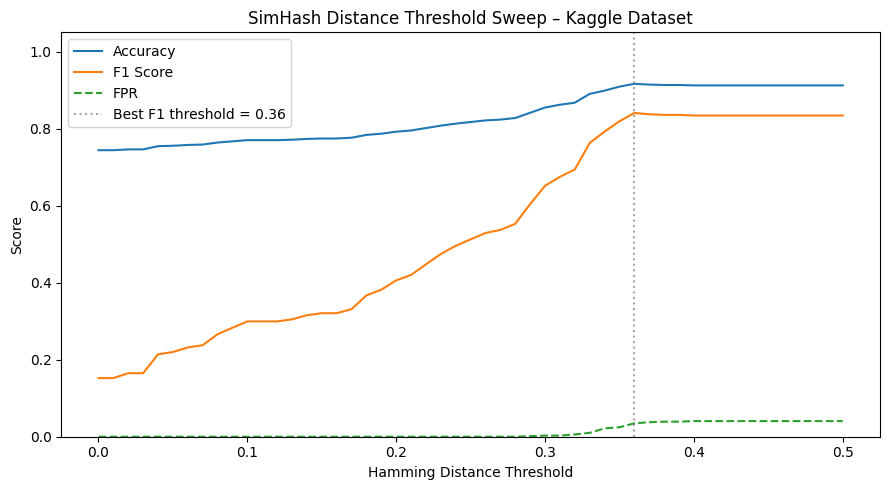

Threshold sweep plot saved.


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh_df["threshold"], thresh_df["acc"], label="Accuracy", marker="")
ax.plot(thresh_df["threshold"], thresh_df["f1"],  label="F1 Score",  marker="")
ax.plot(thresh_df["threshold"], thresh_df["fpr"], label="FPR",       marker="", linestyle="--")
ax.axvline(best_thresh_row["threshold"], color="grey", linestyle=":", alpha=0.7,
           label=f"Best F1 threshold = {best_thresh_row['threshold']}")
ax.set_xlabel("Hamming Distance Threshold")
ax.set_ylabel("Score")
ax.set_title("SimHash Distance Threshold Sweep – Kaggle Dataset")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(results_dir / "kaggle_simhash_threshold_sweep.png", dpi=150)
plt.show()
print("Threshold sweep plot saved.")

## 13. Confusion Matrix

This section shows the confusion matrix for the best kNN configuration on the held-out test set.

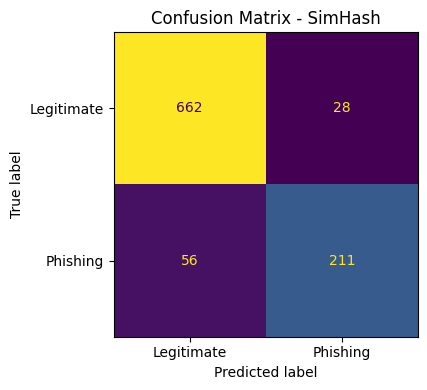

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path
import matplotlib.pyplot as plt
 
cm = confusion_matrix(test_labels, preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Phishing"]
)
 
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - SimHash")
plt.tight_layout()
 
figures_dir = Path("../results/figures/")
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "kaggle_cm_simhash.png", dpi=150)
 
plt.show()

## 14. Save Results

This section appends final results to the shared project results CSV for cross-model comparison.

In [14]:
results_csv = results_dir / "all_results.csv"

results_row = pd.DataFrame([final_results])

if results_csv.exists():
    existing = pd.read_csv(results_csv)
    # Remove any previous SimHash/Kaggle row to avoid duplicates on re-run
    existing = existing[~((existing["Model"] == "SimHash + kNN") & (existing["Dataset"] == "Kaggle"))]
    combined = pd.concat([existing, results_row], ignore_index=True)
else:
    combined = results_row

combined.to_csv(results_csv, index=False)
print("Results saved to all_results.csv")
print(results_row.to_string(index=False))

Results saved to all_results.csv
        Model Dataset  Accuracy  Precision  Recall    F1    FPR  Inference_ms       Config
SimHash + kNN  Kaggle    0.9122     0.8828  0.7903 0.834 0.0406        0.0347 128-bit, k=1


## 15. Per-Source Breakdown

The Kaggle dataset contains emails from two distinct sources: human-written and LLM-generated. Evaluating separately reveals whether the SimHash + kNN pipeline performs consistently across both types or has a systematic weakness on one source.

In [ ]:
sources_arr = test_df["source"].values
true_arr    = np.array(test_labels)
pred_arr    = np.array(preds)

per_source_rows = []
for src in sorted(test_df["source"].unique()):
    mask   = sources_arr == src
    y_true = true_arr[mask]
    y_pred = pred_arr[mask]

    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    per_source_rows.append({
        "source":    src,
        "n_samples": int(mask.sum()),
        "accuracy":  round(acc, 4),
        "f1":        round(f1,  4),
        "fpr":       round(fpr, 4),
    })

per_source_df = pd.DataFrame(per_source_rows).set_index("source")

print("Per-Source Evaluation — SimHash + kNN (Kaggle)")
print("=" * 50)
print(per_source_df.to_string())

metrics_dir = results_dir / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)
per_source_path = metrics_dir / "kaggle_simhash_per_source_results.csv"
per_source_df.to_csv(per_source_path)
print(f"\nPer-source results saved to {per_source_path}")

Per-Source Evaluation — SimHash + kNN (Kaggle)
                 n_samples  accuracy      f1     fpr
source                                              
human-generated        468    0.8761  0.8407  0.0338
llm-generated          489    0.9468  0.8169  0.0448

Per-source results saved to ../results/metrics/kaggle_simhash_per_source_results.csv
